### Generate Data by Varying $\tau$ and $s$

In [1]:
# Imports
import numpy as np
import pysensors as ps
import os, sys
import matplotlib.pyplot as plt

if "__file__" in globals():
    script_dir = os.path.dirname(os.path.abspath(__file__))
else:
    script_dir = os.getcwd()

utils_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "Utils"))
output_dir = os.path.abspath(os.path.join(script_dir, "..", "Outputs"))

sys.path.append(utils_dir)
from beam_problem import beam_problem as bp
from sobol import generate_sobol
from sensor_processing import sensor_processing
from yaml_processor import load_config, save_config
from data_processing import load_dataset, save_dataset

config_file = os.path.abspath(os.path.join(script_dir, "..", "configuration.yaml"))
config_global = load_config(config_file)

##### Initialization

In [2]:
# Load or Create New Data
load_init = False
load_train = True
load_val = True
load_test = True

In [3]:

T = 1/np.pi  # Time period
tau_param = (T/20, T/2) # Impulse width range
delta_s = (0.5, 0.9) # Impulse location range

param_ranges = [tau_param, delta_s]

omega = 2*np.pi/T # Omega
nt = config_global["data"]["nt"] # number of time steps
nx = config_global["data"]["nx"] # number of spatial points

n_init = 16 # number of initial full space dataset
n_train = 32 # number of initial train params
n_train_minimum = 16 # number of minimum training params per cluster
n_val = 16 # number of validation params per cluster
n_test = 128 # number of test params per cluster 

# Beam Problem
noise_std = 0.001
beam_problem = bp(nx, nt, i_range = range(1, 250), k_range = range(0, 90))

##### Generate Initial Full Space Data

In [4]:
param_init = generate_sobol(2, n_init, param_ranges)

ValueError: x and y can be no greater than 2D, but have shapes (2,) and (2, 200, 101)

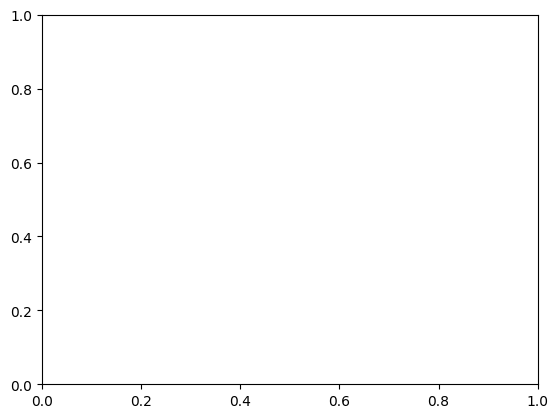

In [ ]:
plt.figure()
a,b = beam_problem.solve(tau = param_init[0, 0], s = param_init[0, 1], omega = omega, cycles=1)
A, B = beam_problem.solve(tau = param_init[0, 0], s = param_init[0, 1], omega = omega, cycles=10)
plt.plot(a[:, 75], b[:, 75])
plt.plot(a[:, 75], b[:, 75])
plt.show()

In [ ]:
if load_init:
    SS_init, param_init = load_dataset(os.path.join(output_dir, "datasets/Init"))
else:
    param_init = generate_sobol(2, n_init, param_ranges)
    SS_init = np.zeros([n_init, 2, nt, nx])

    for i in range(n_init):
        print(f"Init - {i+1}/{n_init}")
        SS_init[i, 0], SS_init[i, 1] = beam_problem.solve(tau = param_init[i, 0], s = param_init[i, 1], omega = omega)
    
    # save dataset
    save_dataset(os.path.join(output_dir, "datasets/Init"), SS_init, param_init, cluster=None)

Init - 1/16
Init - 2/16
Init - 3/16
Init - 4/16
Init - 5/16
Init - 6/16
Init - 7/16
Init - 8/16
Init - 9/16
Init - 10/16
Init - 11/16
Init - 12/16
Init - 13/16
Init - 14/16
Init - 15/16
Init - 16/16


##### Find Optimal Sensor Locations

The preferred number of sensors is: 14


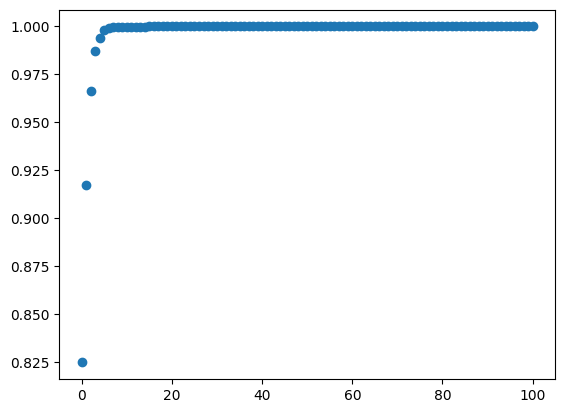

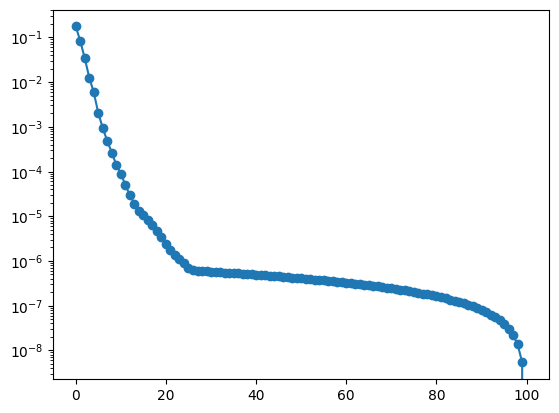

In [10]:
# Initialize sensor locator
sp = sensor_processing(SS_init[:, 1], config_global)
sp.perform_svd()
sp.plot_singular(err_cap = 0.00002)

###### Chose number of sensors

In [11]:
num_sensors = 18

In [12]:
# Apply sensor locator
sp.opt_sensor_loc(num_sensors, fill_gaps=True)
# Save setup
sp.save(output_dir)

Sensors are in [ 8 13 18 23 29 33 38 46 52 57 61 65 70 75 79 83 88 94]


In [13]:
# Save configuration
config_global["data"]["param_bounds"]["tau"] = np.sort(tau_param).tolist()
config_global["data"]["param_bounds"]["s"] = np.sort(delta_s).tolist()
config_global["sensors"]["num_sensors"] = num_sensors
save_config(config_file, config_global)

#### Generate Training Data

In [9]:
if load_train:
    SS_train, param_train = load_dataset(os.path.join(output_dir, "datasets/Train"))
else:
    param_train = generate_sobol(2, n_train, param_ranges)
    SS_train = np.zeros([n_train, 2, nt, nx])

    for i in range(n_train):
        print(f"Train - {i+1}/{n_train}")
        SS_train[i, 0], SS_train[i, 1] = beam_problem.solve(tau = param_train[i, 0], s = param_train[i, 1], omega = omega)

    # save dataset
    save_dataset(os.path.join(output_dir, "datasets/Train"), SS_train, param_train, cluster=None)

#### Generate Validation Data

In [10]:
if load_val:
    SS_val, param_val = load_dataset(os.path.join(output_dir, "datasets/Val"))
else:
    param_val = generate_sobol(2, n_val, param_ranges)
    SS_val = np.zeros([n_val, 2, nt, nx])

    for i in range(n_val):
        print(f"Val - {i+1}/{n_val}")
        SS_val[i, 0], SS_val[i, 1] = beam_problem.solve(tau = param_val[i, 0], s = param_val[i, 1], omega = omega)

    # save dataset
    save_dataset(os.path.join(output_dir, "datasets/Val"), SS_val, param_val, cluster=None)

#### Generate Testing Data

In [11]:
if load_test:
    SS_test, param_test = load_dataset(os.path.join(output_dir, "datasets/Test"))
else:
    param_test = generate_sobol(2, n_test, param_ranges)
    SS_test = np.zeros([n_test, 2, nt, nx])

    for i in range(n_test):
        print(f"Test - {i+1}/{n_test}")
        SS_test[i, 0], SS_test[i, 1] = beam_problem.solve(tau = param_test[i, 0], s = param_test[i, 1], omega = omega)

    # save dataset
    save_dataset(os.path.join(output_dir, "datasets/Test"), SS_test, param_test, cluster=None)